In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/archive (11).zip')



In [ ]:
X = df[['YearsExperience', 'Salary']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
print(df.head())

   Unnamed: 0  YearsExperience   Salary  Cluster
0           0              1.2  39344.0        2
1           1              1.4  46206.0        2
2           2              1.6  37732.0        2
3           3              2.1  43526.0        2
4           4              2.3  39892.0        2


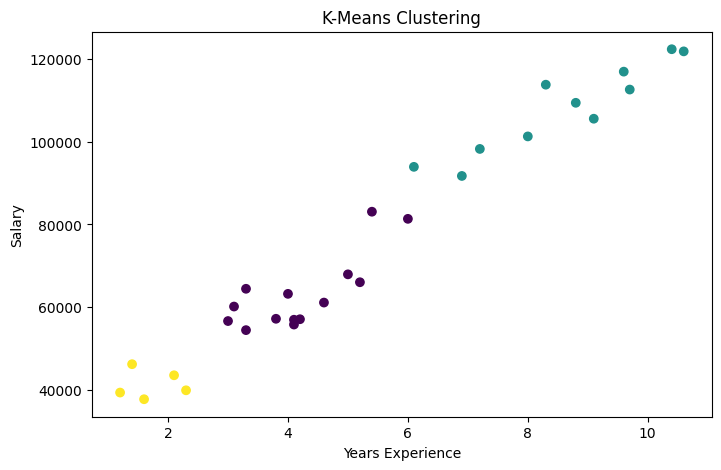

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(df['YearsExperience'],
            df['Salary'],
            c=df['Cluster'])

plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("K-Means Clustering")
plt.show()

**DBSCAN**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [ ]:
df = pd.read_csv('/content/archive (12).zip')

In [ ]:
X = df.iloc[:, 1:]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = clusters

print(df.head())


   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  Cluster  
0        1338        6  
1        1776       -1  
2        7844       -1  
3        1788        0  
4        5185       -1  


In [ ]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print("Number of Clusters:", n_clusters)

Number of Clusters: 8


In [ ]:
print(df['Cluster'].value_counts())

Cluster
-1    235
 0    140
 4     22
 3     12
 2      8
 6      7
 5      6
 1      5
 7      5
Name: count, dtype: int64


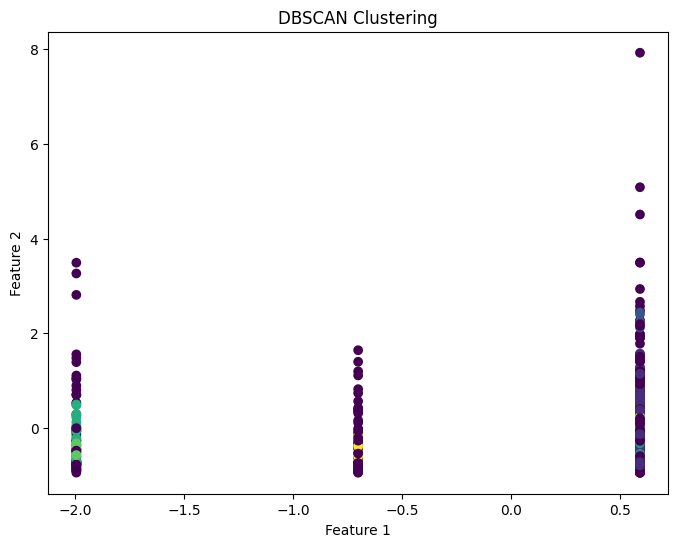

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**PCA**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('/content/archive (13).zip')

In [ ]:
X = df.select_dtypes(include=['int64', 'float64'])

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


In [ ]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

print(pca_df.head())


        PC1       PC2
0 -1.215133 -1.794555
1 -0.467435 -2.477990
2 -0.401695 -1.871949
3  2.645247  0.100493
4 -1.216916 -1.792910


In [ ]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Variance Explained:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.25192323 0.17625364]
Total Variance Explained:
0.4281768675866429


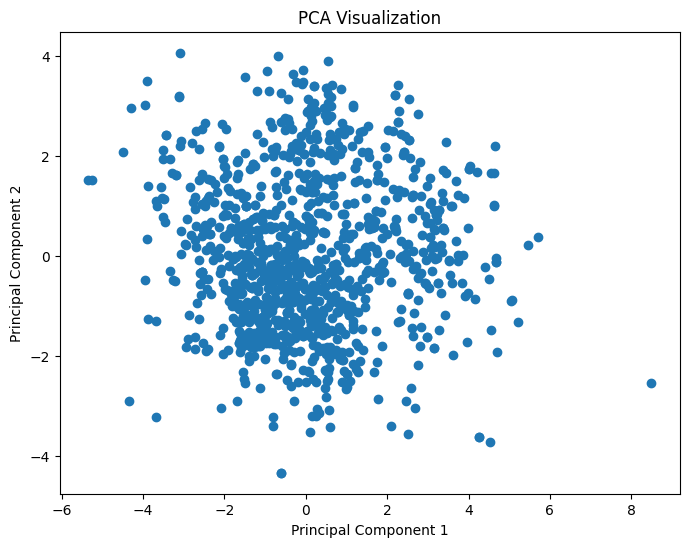

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2']
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')

plt.show()

**APRIORI**


In [ ]:
!pip install mlxtend

In [ ]:
import pandas as pd

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:

transactions = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Eggs'],
    ['Milk', 'Bread'],
    ['Milk', 'Eggs'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Eggs', 'Butter']
]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print(df.head())


   Bread  Butter   Eggs   Milk
0   True    True  False   True
1   True   False   True  False
2   True   False  False   True
3  False   False   True   True
4   True    True  False  False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
frequent_itemsets = apriori(
    df,
    min_support=0.3,
    use_colnames=True
)

print("\nFrequent Itemsets:")
print(frequent_itemsets)


Frequent Itemsets:
    support               itemsets
0  0.833333                (Bread)
1  0.500000               (Butter)
2  0.500000                 (Eggs)
3  0.666667                 (Milk)
4  0.500000        (Bread, Butter)
5  0.333333          (Bread, Eggs)
6  0.500000          (Milk, Bread)
7  0.333333         (Milk, Butter)
8  0.333333           (Milk, Eggs)
9  0.333333  (Milk, Bread, Butter)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

print("\nAssociation Rules:")
print(rules[['antecedents',
             'consequents',
             'support',
             'confidence',
             'lift']])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Association Rules:
        antecedents      consequents   support  confidence      lift
0           (Bread)         (Butter)  0.500000    0.600000  1.200000
1          (Butter)          (Bread)  0.500000    1.000000  1.200000
2            (Eggs)          (Bread)  0.333333    0.666667  0.800000
3            (Milk)          (Bread)  0.500000    0.750000  0.900000
4           (Bread)           (Milk)  0.500000    0.600000  0.900000
5            (Milk)         (Butter)  0.333333    0.500000  1.000000
6          (Butter)           (Milk)  0.333333    0.666667  1.000000
7            (Milk)           (Eggs)  0.333333    0.500000  1.000000
8            (Eggs)           (Milk)  0.333333    0.666667  1.000000
9     (Milk, Bread)         (Butter)  0.333333    0.666667  1.333333
10   (Milk, Butter)          (Bread)  0.333333    1.000000  1.200000
11  (Bread, Butter)           (Milk)  0.333333    0.666667  1.000000
12           (Milk)  (Bread, Butter)  0.333333    0.500000  1.000000
13         (Bu

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag